In [60]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from gan_eval import (
    # —— evaluator.py ——
    GANEvaluator, ALL_METRICS,
    # —— tracker.py ——
    FIDTracker,
    # —— data.py ——
    list_images, make_loader, ImageFolderDataset,
    # —— inception.py ——
    InceptionFeatureExtractor,
    # —— metrics.py ——
    frechet_distance, kernel_inception_distance, inception_score,
    memorization_distance, memorization_informed_fid,
    improved_precision_recall, format_results,
)
from gan_models import Generator, Discriminator, weights_init
from gan_data import dog_dataloader, make_dataloader, PTImageDataset, FolderImageDataset
from fid_plot import plot_fid
from IPython.display import Image, display

device = 'cuda' if torch.cuda.is_available() else 'cpu'
z_dim = 100
print(device)

cuda


In [61]:
#---------------dataloader------------------------
data_loader = dog_dataloader(batch_size = 64, val_split = 0.0)

In [62]:
#---------------net generate-----------------------
G = Generator(z_dim = 100, ngf = 64, nc = 3)
D = Discriminator(ndf = 64, nc = 3)
G.apply(weights_init).to(device)
D.apply(weights_init).to(device)

Discriminator(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=1, 

In [63]:
#-----------------------eval---------------------
ev = GANEvaluator(real_dir=r"C:\Users\moneyforever\Desktop\Deep-Learning\Kaggle\data\all-dogs",
                  image_size=64, device=device)          # 真实特征只算一次并缓存
tracker = FIDTracker(ev, out_dir="outputs/dcgan", every=5,
                     num_samples=2000, metrics=("fid","mifid","kid","is"))

def sample_fn(n, seed):            # 供 FIDTracker 调用
    g = torch.Generator(device=device).manual_seed(seed)
    G.eval()
    with torch.no_grad():
        z = torch.randn(n, z_dim, 1, 1, generator=g, device=device)
        imgs = G(z)
    G.train()
    return ((imgs.clamp(-1,1)+1)*127.5).round().to(torch.uint8).cpu()


real features:   0%|          | 0/322 [00:00<?, ?it/s]

fake features:   0%|          | 0/32 [00:00<?, ?it/s]

[epoch    5] fid=315.772  mifid=315.772


fake features:   0%|          | 0/32 [00:00<?, ?it/s]

[epoch   10] fid=310.706  mifid=310.706


...

[epoch  290] fid=90.775  mifid=90.775


fake features:   0%|          | 0/32 [00:00<?, ?it/s]

[epoch  295] fid=89.377  mifid=89.377


fake features:   0%|          | 0/32 [00:00<?, ?it/s]

[epoch  300] fid=89.129  mifid=89.129


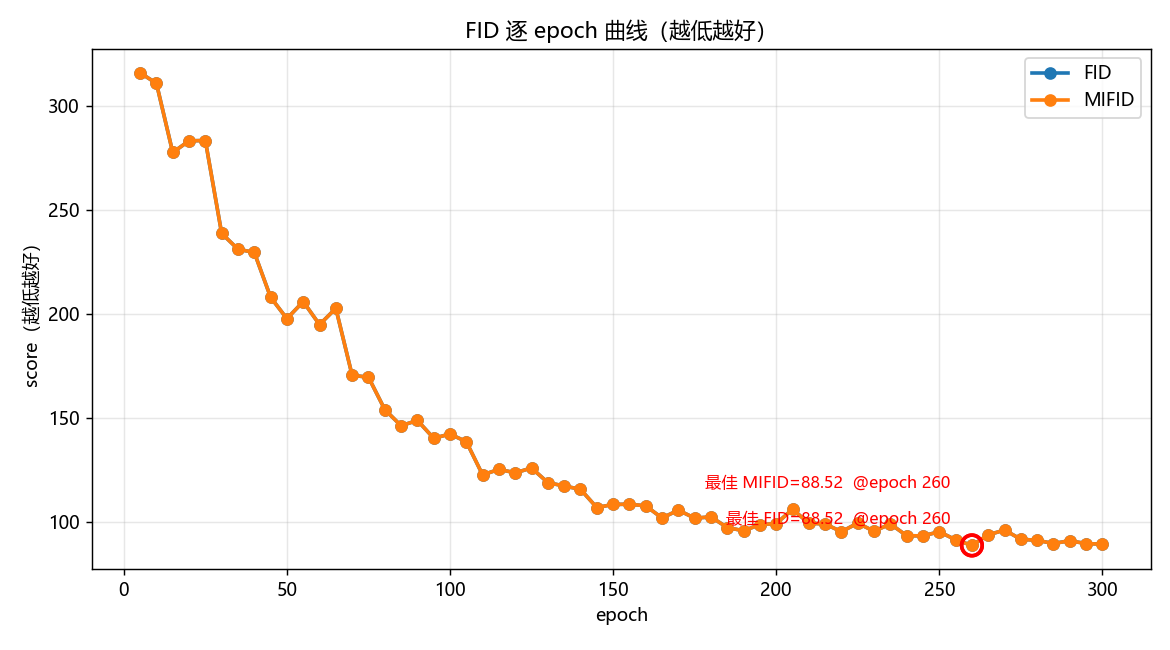

best: {'fid': 88.51601694280151, 'mifid': 88.51601694280151, 'memorization_distance': 0.23588126295254336, 'penalty': 1.0, 'kid': 0.06327814949103712, 'kid_std': 0.0018775303012915888, 'is': 6.310604960076532, 'is_std': 0.42303735835513373, 'epoch': 260}


In [64]:
#-------------------train--------------------------
NOISE = 0.01
num_epochs = 300
opt_G = torch.optim.Adam(G.parameters(), lr = 2e-4)
opt_D = torch.optim.Adam(D.parameters(), lr = 2e-4)
loss = nn.BCELoss()
for epoch in range(num_epochs):
    D.train()
    for real in data_loader:
        real = real.to(device)
        batch = real.size(0)
        z = torch.randn(batch, z_dim, 1, 1, device = device)
        fake = G(z)
        true_label = torch.full((batch,), 0.9).to(device)
        fake_label = torch.full((batch,), 0.0).to(device)
        D_true_loss = loss(D(real), true_label)
        D_fake_loss = loss(D(fake.detach()), fake_label)
        D_avg_loss = (D_true_loss + D_fake_loss) / 2
        opt_D.zero_grad()
        D_avg_loss.backward()
        opt_D.step()

        G.train()
        z = torch.randn(batch, z_dim, 1, 1, device = device)
        G_loss = loss(D(G(z)), true_label)
        opt_G.zero_grad()
        G_loss.backward()
        opt_G.step()

    
    if (epoch+1) % tracker.every == 0:               # ← 评估接入点
        tracker.step(epoch+1, sample_fn)           # gan_eval.tracker

display(Image(plot_fid(tracker)))
print("best:", tracker.best_epoch("fid"))

In [66]:
import torch
G.eval()
with torch.no_grad():
    z = torch.randn(2000, 100, 1, 1, device=device)
    fake = G(z)                                              # [-1,1]
fake_uint8 = ((fake.clamp(-1,1) + 1) * 127.5).to(torch.uint8).cpu()

scores = ev.evaluate(fake_uint8, metrics=("fid","mifid","kid","is","pr"))
print(ev.report(scores))

fake features:   0%|          | 0/32 [00:00<?, ?it/s]

  FID (lower better)                : 88.988
  MiFID (lower better)              : 88.988
  Memorization distance             : 0.2356
  Memorization penalty              : 1.000
  KID x1000 (lower better)          : 65.0084
  KID std                           : 0.0017
  Inception Score (higher better)   : 6.413
  IS std                            : 0.402
  Precision (quality)               : 0.4180
  Recall (diversity)                : 0.4345
